In [1]:
import pandas as pd
import numpy as np

hb=pd.read_csv("heart_dataset.csv")


In [2]:
hb = hb.replace(r'^\s*$', np.nan, regex=True)

print(hb.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [3]:
print(hb.loc[hb["fbs"].isna(), "fbs"].head())

330    NaN
384    NaN
410    NaN
434    NaN
447    NaN
Name: fbs, dtype: object


In [9]:
# Target
X = hb.drop(columns=["num","id","dataset"])
y = hb["num"]

print("Features:", X.shape)
print("Target distribution:")
print(y.value_counts().sort_index())

Features: (920, 13)
Target distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (736, 13)
Testing: (184, 13)


In [13]:
X_encoded = X.copy()

categorical_features = X_encoded.select_dtypes(
    include=["object", "string"]
).columns

for col in categorical_features:
    X_encoded[col] = X_encoded[col].astype("category").cat.codes
    X_encoded[col] = X_encoded[col].replace(-1, float("nan"))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Sample weights created.")

Sample weights created.


In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

balanced_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    random_state=42
)

balanced_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [23]:
balanced_pred = balanced_model.predict(X_test)

print("Balanced Model Accuracy:",
      accuracy_score(y_test, balanced_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    balanced_pred,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    balanced_pred
))

Balanced Model Accuracy: 0.5706521739130435

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80        82
           1       0.53      0.49      0.51        53
           2       0.29      0.27      0.28        22
           3       0.23      0.29      0.26        21
           4       0.00      0.00      0.00         6

    accuracy                           0.57       184
   macro avg       0.37      0.37      0.37       184
weighted avg       0.56      0.57      0.56       184


Confusion Matrix:
[[67 10  2  3  0]
 [11 26  7  8  1]
 [ 4  6  6  6  0]
 [ 3  7  4  6  1]
 [ 1  0  2  3  0]]


In [24]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    balanced_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro"
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

     Feature  Importance
9    oldpeak    0.035577
2         cp    0.033906
4       chol    0.021487
11        ca    0.011428
0        age    0.010554
6    restecg    0.010163
10     slope    0.007329
1        sex    0.007070
8      exang    0.004392
3   trestbps   -0.000843
12      thal   -0.002971
7     thalch   -0.005881
5        fbs   -0.015059


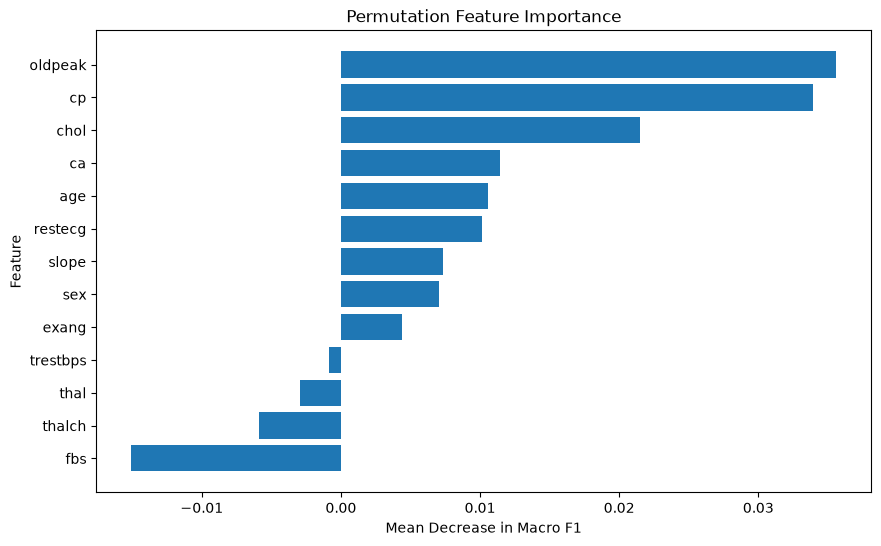

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Mean Decrease in Macro F1")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()
plt.show()

In [26]:
# Create category mappings from the original dataset
category_maps = {}

for col in categorical_features:
    categories = X[col].astype("category").cat.categories
    
    category_maps[col] = {
        category: code
        for code, category in enumerate(categories)
    }

print("Category mappings:")
for col, mapping in category_maps.items():
    print(f"\n{col}:")
    print(mapping)

Category mappings:

sex:
{'Female': 0, 'Male': 1}

cp:
{'asymptomatic': 0, 'atypical angina': 1, 'non-anginal': 2, 'typical angina': 3}

fbs:
{False: 0, True: 1}

restecg:
{'lv hypertrophy': 0, 'normal': 1, 'st-t abnormality': 2}

exang:
{False: 0, True: 1}

slope:
{'downsloping': 0, 'flat': 1, 'upsloping': 2}

thal:
{'fixed defect': 0, 'normal': 1, 'reversable defect': 2}


In [27]:
import joblib

model_package = {
    "model": balanced_model,
    "category_maps": category_maps,
    "categorical_features": categorical_features.tolist(),
    "feature_columns": X_train.columns.tolist(),
    "target_classes": sorted(y.unique().tolist())
}

joblib.dump(
    model_package,
    "models/heart_disease_model.joblib"
)

print("Model and preprocessing information saved successfully.")

Model and preprocessing information saved successfully.
